In [1]:
pip install --upgrade scikeras scikit-learn -q

In [2]:
# Install SciKeras for hyperparameter tuning later
!pip install scikeras -q

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)
from sklearn.model_selection import RandomizedSearchCV

np.random.seed(42)
tf.random.set_seed(42)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape: (10000, 28, 28)
Testing labels shape: (10000,)


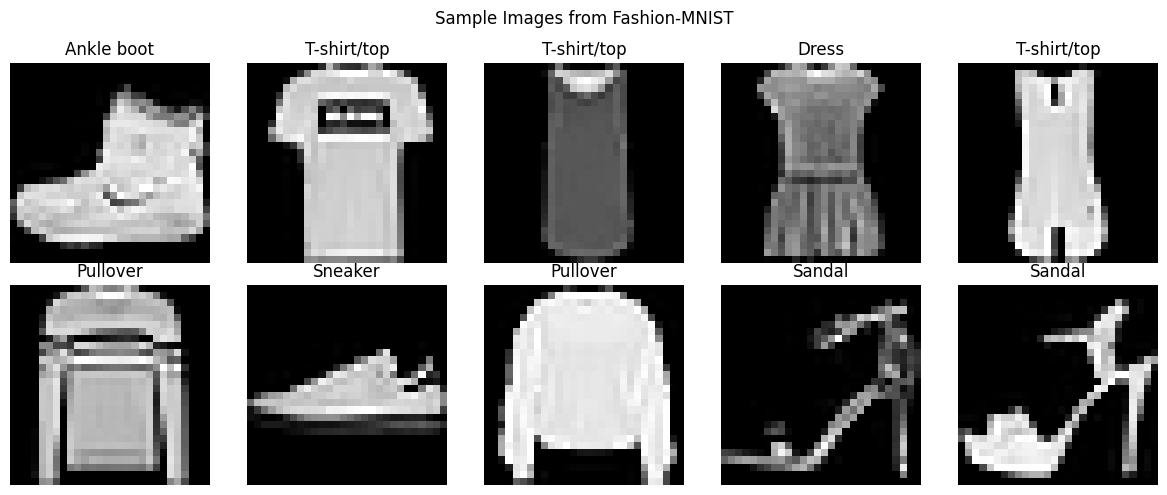

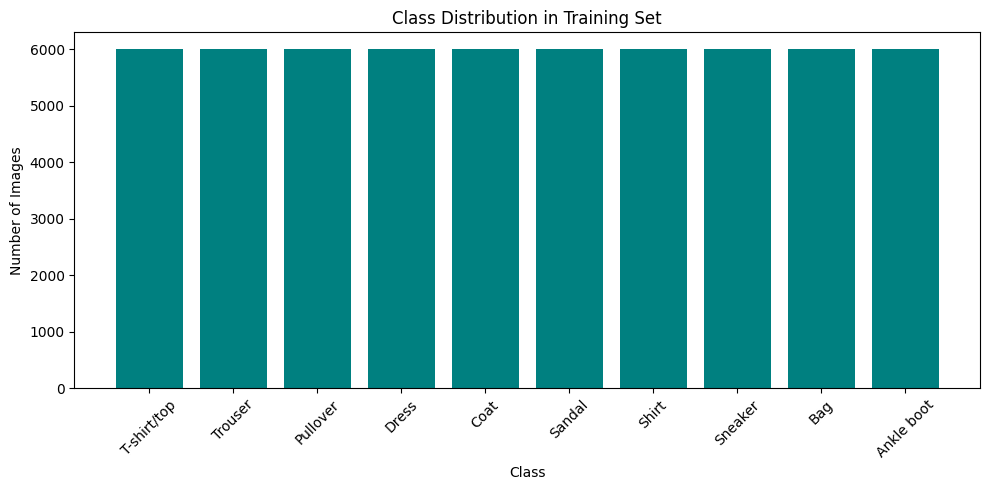

In [3]:
# Load Fashion-MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

# Display 10 sample images
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle("Sample Images from Fashion-MNIST")
plt.tight_layout()
plt.show()

# Plot class distribution
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(10, 5))
plt.bar([class_names[i] for i in unique], counts, color='teal')
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution in Training Set")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
print("Shape before preprocessing:")
print("x_train:", x_train.shape, "| x_test:", x_test.shape)

# Normalize pixel values to [0, 1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

# Flatten images: 28x28 -> 784
x_train_flat = x_train_norm.reshape(x_train_norm.shape[0], 784)
x_test_flat = x_test_norm.reshape(x_test_norm.shape[0], 784)

# One-hot encode labels
y_train_ohe = keras.utils.to_categorical(y_train, num_classes=10)
y_test_ohe = keras.utils.to_categorical(y_test, num_classes=10)

print("\nShape after preprocessing:")
print("x_train_flat:", x_train_flat.shape, "| x_test_flat:", x_test_flat.shape)
print("y_train_ohe:", y_train_ohe.shape, "| y_test_ohe:", y_test_ohe.shape)

Shape before preprocessing:
x_train: (60000, 28, 28) | x_test: (10000, 28, 28)

Shape after preprocessing:
x_train_flat: (60000, 784) | x_test_flat: (10000, 784)
y_train_ohe: (60000, 10) | y_test_ohe: (10000, 10)


In [5]:
def build_baseline_model():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

baseline_model = build_baseline_model()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = baseline_model.fit(
    x_train_flat, y_train_ohe,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.9381 - loss: 0.1618 - val_accuracy: 0.8866 - val_loss: 0.4048
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9399 - loss: 0.1566 - val_accuracy: 0.8847 - val_loss: 0.4254
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9420 - loss: 0.1505 - val_accuracy: 0.8861 - val_loss: 0.4484
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9444 - loss: 0.1464 - val_accuracy: 0.8870 - val_loss: 0.4549
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9450 - loss: 0.1446 - val_accuracy: 0.8802 - val_loss: 0.4739
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9474 - loss: 0.1387 - val_accuracy: 0.8813 - val_loss: 0.4800
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9474 - loss: 0.1364 - val_accuracy: 0.8808 - val_loss: 0.5172
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9491 - loss: 0.1324

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy:  0.8744
Precision: 0.8795
Recall:    0.8744
F1-score:  0.8754


<Figure size 1000x800 with 0 Axes>

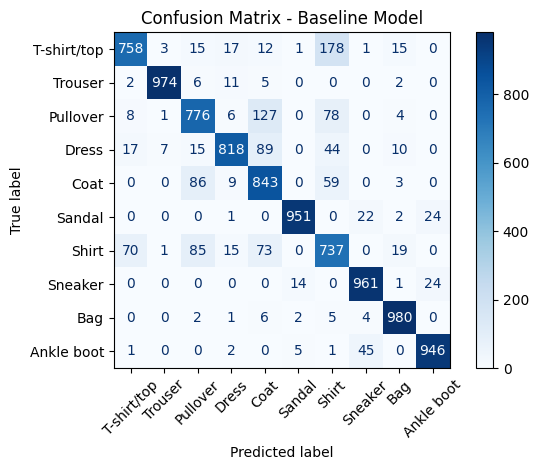


Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.89      0.76      0.82      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.79      0.78      0.78      1000
       Dress       0.93      0.82      0.87      1000
        Coat       0.73      0.84      0.78      1000
      Sandal       0.98      0.95      0.96      1000
       Shirt       0.67      0.74      0.70      1000
     Sneaker       0.93      0.96      0.95      1000
         Bag       0.95      0.98      0.96      1000
  Ankle boot       0.95      0.95      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.88     10000
weighted avg       0.88      0.87      0.88     10000



In [7]:
# Predictions
y_pred_probs = baseline_model.predict(x_test_flat)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_ohe, axis=1)

# Metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Baseline Model")
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

In [11]:
from scikeras.wrappers import KerasClassifier

def create_model(hidden_layers=2, neurons=128, learning_rate=0.001,
                  optimizer='adam', activation='relu', dropout_rate=0.0):
    model = keras.Sequential()
    model.add(layers.Input(shape=(784,)))
    for _ in range(hidden_layers):
        model.add(layers.Dense(neurons, activation=activation))
        if dropout_rate > 0.0:
            model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(10, activation='softmax'))

    if optimizer == 'adam':
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

clf = KerasClassifier(
    model=create_model,
    verbose=0,
    hidden_layers=2,
    neurons=128,
    learning_rate=0.001,
    optimizer='adam',
    activation='relu',
    dropout_rate=0.0,
    epochs=5,
    batch_size=64
)

# Smaller search space, capped epochs to keep each fit quick
param_dist = {
    'model__hidden_layers': [1, 2, 3],
    'model__neurons': [32, 64, 128, 256],
    'model__learning_rate': [0.1, 0.01, 0.001],
    'model__optimizer': ['sgd', 'adam', 'rmsprop'],
    'model__activation': ['relu', 'tanh', 'sigmoid'],
    'model__dropout_rate': [0.0, 0.2, 0.5],
    'batch_size': [32, 64, 128],   # dropped 16 -> slowest option
    'epochs': [5, 10]              # capped -> was up to 30
}

# Much smaller subset for search speed
subset_size = 2000
x_search = x_train_flat[:subset_size]
y_search = y_train[:subset_size]

random_search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=5,      # was 15 -> now 5 candidates
    cv=2,          # was 5 -> now 2 folds
    verbose=1,
    random_state=42,
    n_jobs=1
)

random_search_result = random_search.fit(x_search, y_search)

print("Best Score: %.4f" % random_search_result.best_score_)
print("Best Params:", random_search_result.best_params_)

Fitting 2 folds for each of 5 candidates, totalling 10 fits


Best Score: 0.7775
Best Params: {'model__optimizer': 'sgd', 'model__neurons': 128, 'model__learning_rate': 0.1, 'model__hidden_layers': 2, 'model__dropout_rate': 0.0, 'model__activation': 'tanh', 'epochs': 10, 'batch_size': 128}


In [14]:
best_params = random_search_result.best_params_

optimized_model = create_model(
    hidden_layers=best_params['model__hidden_layers'],
    neurons=best_params['model__neurons'],
    learning_rate=best_params['model__learning_rate'],
    optimizer=best_params['model__optimizer'],
    activation=best_params['model__activation'],
    dropout_rate=best_params['model__dropout_rate']
)

opt_history = optimized_model.fit(
    x_train_flat, y_train,          # integer labels, not y_train_ohe
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    validation_split=0.2,
    verbose=1
)

# Evaluate optimized model
y_pred_opt = np.argmax(optimized_model.predict(x_test_flat), axis=1)

acc_opt = accuracy_score(y_true, y_pred_opt)
prec_opt = precision_score(y_true, y_pred_opt, average='weighted')
rec_opt = recall_score(y_true, y_pred_opt, average='weighted')
f1_opt = f1_score(y_true, y_pred_opt, average='weighted')

print(f"Optimized Accuracy:  {acc_opt:.4f}")
print(f"Optimized Precision: {prec_opt:.4f}")
print(f"Optimized Recall:    {rec_opt:.4f}")
print(f"Optimized F1-score:  {f1_opt:.4f}")

print(f"\nBaseline vs Optimized Accuracy: {acc:.4f} -> {acc_opt:.4f}")

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7775 - loss: 0.6262 - val_accuracy: 0.8267 - val_loss: 0.4857
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8341 - loss: 0.4589 - val_accuracy: 0.8451 - val_loss: 0.4365
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8486 - loss: 0.4186 - val_accuracy: 0.8536 - val_loss: 0.4135
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8579 - loss: 0.3934 - val_accuracy: 0.8572 - val_loss: 0.4001
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8643 - loss: 0.3749 - val_accuracy: 0.8583 - val_loss: 0.3911
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8693 - loss: 0.3602 - val_accuracy: 0.8590 - val_loss: 0.3845
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8736 - loss: 0.3478 - val_accuracy: 0.8605 - val_loss: 0.3794
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8779 - loss: 0.3369 - val_accuracy: 0

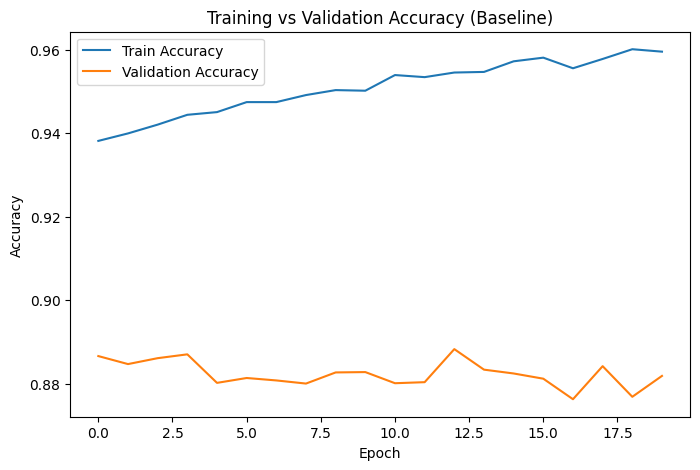

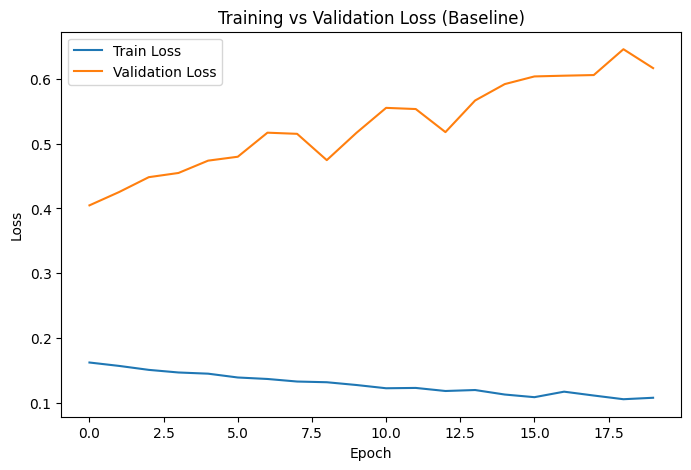

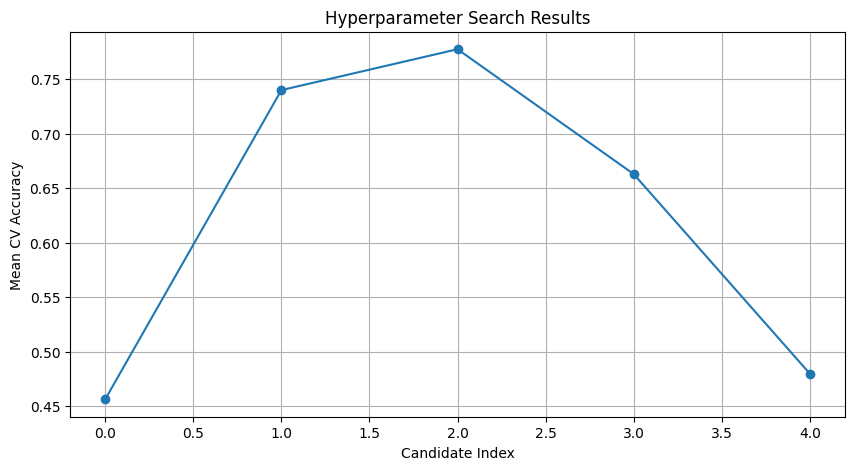

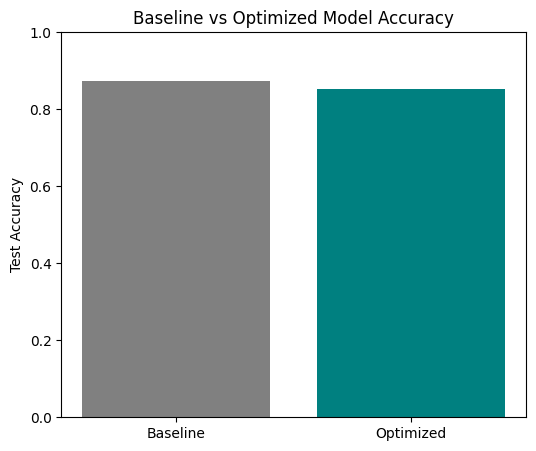

In [15]:
# Training vs Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy (Baseline)')
plt.legend()
plt.show()

# Training vs Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Baseline)')
plt.legend()
plt.show()

# Hyperparameter search results (mean test scores per candidate)
results = random_search_result.cv_results_
plt.figure(figsize=(10, 5))
plt.plot(results['mean_test_score'], marker='o')
plt.xlabel('Candidate Index')
plt.ylabel('Mean CV Accuracy')
plt.title('Hyperparameter Search Results')
plt.grid(True)
plt.show()

# Best Model Accuracy Comparison
plt.figure(figsize=(6, 5))
plt.bar(['Baseline', 'Optimized'], [acc, acc_opt], color=['gray', 'teal'])
plt.ylabel('Test Accuracy')
plt.title('Baseline vs Optimized Model Accuracy')
plt.ylim(0, 1)
plt.show()